# Analisis Sentimen Ulasan Steam: *Where Winds Meet*
Notebook ini membahas analisis sentimen ulasan Steam secara end-to-end, mulai dari pengambilan data hingga evaluasi model Deep Learning.

## Tujuan Analisis
Notebook ini menyajikan alur analisis sentimen ulasan Steam untuk game *Where Winds Meet*: pengambilan data, pemeriksaan awal, pembersihan teks, eksplorasi distribusi sentimen, tokenisasi, pelatihan model, dan evaluasi.

## 1. Persiapan Library
Mengimpor library yang diperlukan untuk scraping, pengolahan data, visualisasi, dan pemodelan teks.

In [1]:
import json
import requests
import pandas as pd
import time
import re
import string
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Conv1D, GlobalMaxPooling1D, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

e:\miniconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 2. Pengumpulan Data (Scraping)
Pada tahap ini, ulasan game *Where Winds Meet* diambil dari Steam Web API untuk digunakan sebagai dataset analisis sentimen.

### Mengambil Ulasan Steam
Fungsi berikut mengambil ulasan berbahasa Inggris secara bertahap berdasarkan App ID game, kemudian membatasi jumlah data sesuai kebutuhan analisis.

In [2]:
# Isi lokasi dan nama file cache ulasan di sini.
DATA_DIRECTORY = Path('')
DATA_FILENAME = 'dataset.json'
UPDATE_DATASET = False  # Ubah ke True jika ingin mengambil data terbaru dari Steam.
DATA_PATH = DATA_DIRECTORY / DATA_FILENAME


def get_steam_reviews(app_id, max_reviews=3500):
    reviews = []
    cursor = '*'
    print(f"Memulai scraping ulasan Steam untuk App ID {app_id}...")

    while len(reviews) < max_reviews:
        url = f"https://store.steampowered.com/appreviews/{app_id}"
        params = {
            'json': 1,
            'filter': 'recent',
            'language': 'english', # Mengambil teks berbahasa Inggris agar seragam
            'cursor': cursor,
            'review_type': 'all',
            'purchase_type': 'all',
            'num_per_page': 100
        }

        response = requests.get(url, params=params, timeout=30)
        if response.status_code != 200:
            print("Gagal mengambil data dari API Steam.")
            break

        data = response.json()
        if 'reviews' not in data or not data['reviews']:
            break

        reviews.extend(data['reviews'])
        cursor = data['cursor']
        print(f"Terkumpul {len(reviews)} ulasan...")
        time.sleep(1)

    return reviews[:max_reviews]


# Gunakan cache yang sudah ada, kecuali pembaruan diminta secara eksplisit.
app_id_where_winds_meet = 3564740
if DATA_PATH.exists() and not UPDATE_DATASET:
    with DATA_PATH.open('r', encoding='utf-8') as file:
        hasil_scraping = json.load(file)

    # Samakan nama kolom agar data lama dengan kolom 'content' tetap kompatibel.
    if isinstance(hasil_scraping, list):
        for review_data in hasil_scraping:
            if 'content' in review_data and 'review' not in review_data:
                review_data['review'] = review_data.pop('content')

    print(f"Memuat {len(hasil_scraping)} ulasan dari {DATA_PATH}.")
else:
    hasil_scraping = get_steam_reviews(app_id_where_winds_meet, max_reviews=50000)
    if hasil_scraping:
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        with DATA_PATH.open('w', encoding='utf-8') as file:
            json.dump(hasil_scraping, file, ensure_ascii=False, indent=2)
        print(f"Data tersimpan di {DATA_PATH}.")
    else:
        print("Tidak ada ulasan yang berhasil diambil; file cache tidak diubah.")

print(f"Total ulasan yang tersedia: {len(hasil_scraping)}")

Memuat 50000 ulasan dari dataset.json.
Total ulasan yang tersedia: 50000


### Pratinjau Hasil Scraping
Beberapa baris data ditampilkan untuk memeriksa struktur ulasan dan label sentimen sebelum dataset dibentuk.

In [3]:
display(pd.DataFrame(hasil_scraping).head())

,voted_up,label,sentiment,review
0,True,1,Positif,The best thing about this update is how natura...
1,True,1,Positif,This chapter understands that spectacle is bet...
2,True,1,Positif,The finale works because the old conflicts hav...
3,True,1,Positif,Nice game
4,True,1,Positif,"I expected a new map, but the update gave me a..."


## 3. Penyusunan Dataset
Mengubah hasil scraping menjadi DataFrame dengan kolom teks ulasan dan label sentimen yang siap diproses.

### Penentuan Label
- 0 -> Thumbs Down
- 1 -> Thumbs Up
- 2 -> Diambil berdasarkan skor sentimen VADER yang mendekati 0

In [4]:
# Ubah ke DataFrame
try:
    sia = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download('vader_lexicon', quiet=True)
    sia = SentimentIntensityAnalyzer()

reviews_df = pd.DataFrame(hasil_scraping)
if 'content' in reviews_df.columns and 'review' not in reviews_df.columns:
    reviews_df = reviews_df.rename(columns={'content': 'review'})

raw_df = reviews_df[['review', 'voted_up']].dropna(subset=['review'])
df = raw_df.rename(columns={'review': 'content'})

# Steam hanya menyediakan thumbs up/down. Kelas netral dibuat dari review
# dengan skor sentimen VADER yang sangat dekat dengan nol.
def tentukan_label(row):
    compound = sia.polarity_scores(str(row['content']))['compound']
    if -0.05 <= compound <= 0.05:
        return 2
    return int(bool(row['voted_up']))

df['label'] = df.apply(tentukan_label, axis=1)
df['sentiment'] = df['label'].map({0: 'Negatif', 1: 'Positif', 2: 'Netral'})

# 0 = negatif, 1 = positif, 2 = netral (weak label berbasis VADER)
df.to_json('dataset.json', orient='records', force_ascii=False)
df[['content', 'label', 'sentiment']]

,content,label,sentiment
0,The best thing about this update is how natura...,1,Positif
1,This chapter understands that spectacle is bet...,1,Positif
2,The finale works because the old conflicts hav...,1,Positif
3,Nice game,1,Positif
4,"I expected a new map, but the update gave me a...",1,Positif
...,...,...,...
49995,Can finally live out my true passion of achiev...,1,Positif
49996,So far so good. I have not done much in online...,1,Positif
49997,"Wanderer defies fate, weaving a tapestry of ad...",1,Positif
49998,the graphics are insane and for a free open wo...,1,Positif


### Skema Pelabelan Tiga Kelas
Steam hanya menyediakan label asli `voted_up` dan `voted_down`. Untuk memenuhi kebutuhan tiga kelas tanpa mengklaim Steam menyediakan label netral, review dengan skor VADER pada rentang `[-0.05, 0.05]` diberi label **Netral** sebagai weak label. Review lain tetap memakai label thumbs up/down dari Steam. Karena netral berasal dari aturan berbasis teks, hasil model perlu ditafsirkan sebagai eksperimen weak supervision.

In [5]:
df['sentiment'].value_counts()

sentiment
Positif    35439
Netral      9332
Negatif     5229
Name: count, dtype: int64

## 4. Pembersihan Teks
Membersihkan teks ulasan dari URL, tanda baca, angka, duplikat, dan baris kosong agar data lebih konsisten untuk pemodelan.

In [6]:
def bersihkan_teks(teks):
    teks = str(teks).lower() # Case folding
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks) # Hapus URL
    teks = re.sub(f"[{re.escape(string.punctuation)}]", "", teks) # Hapus tanda baca
    teks = re.sub(r'\d+', '', teks) # Hapus angka
    teks = teks.strip()
    return teks

df['cleaned_content'] = df['content'].apply(bersihkan_teks)

# Hapus duplikat dan baris kosong
df = df.drop_duplicates(subset=['cleaned_content'])
df = df.dropna(subset=['cleaned_content'])
df = df[df['cleaned_content'] != ""]

print(f"Data siap setelah pembersihan: {len(df)} baris.")

Data siap setelah pembersihan: 39349 baris.


## 5. Pembagian Data
Menetapkan fitur teks dan label, lalu membagi data menjadi training set, validation set, dan testing set dengan stratifikasi label.

In [7]:
X = df['cleaned_content']
y = df['label']

# Split yang sama digunakan oleh ketiga model agar perbandingan adil
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train, train_size=0.8, random_state=42, stratify=y_train
)

## 6. Exploratory Data Analysis (EDA)
Menganalisis distribusi label sentimen, panjang ulasan, dan kata yang paling sering muncul melalui grafik serta Word Cloud.

### Distribusi Label dan Panjang Ulasan
Menghitung jumlah kata pada setiap ulasan dan membandingkan distribusi panjang teks untuk sentimen negatif dan positif.

### Word Cloud Ulasan
Membuat Word Cloud terpisah untuk ulasan positif dan negatif agar karakteristik kosakata tiap kelas dapat diamati.

Visualisasi berikut digunakan untuk melihat ketidakseimbangan kelas, variasi panjang ulasan, dan kata-kata dominan sebelum data diubah menjadi sequence numerik.

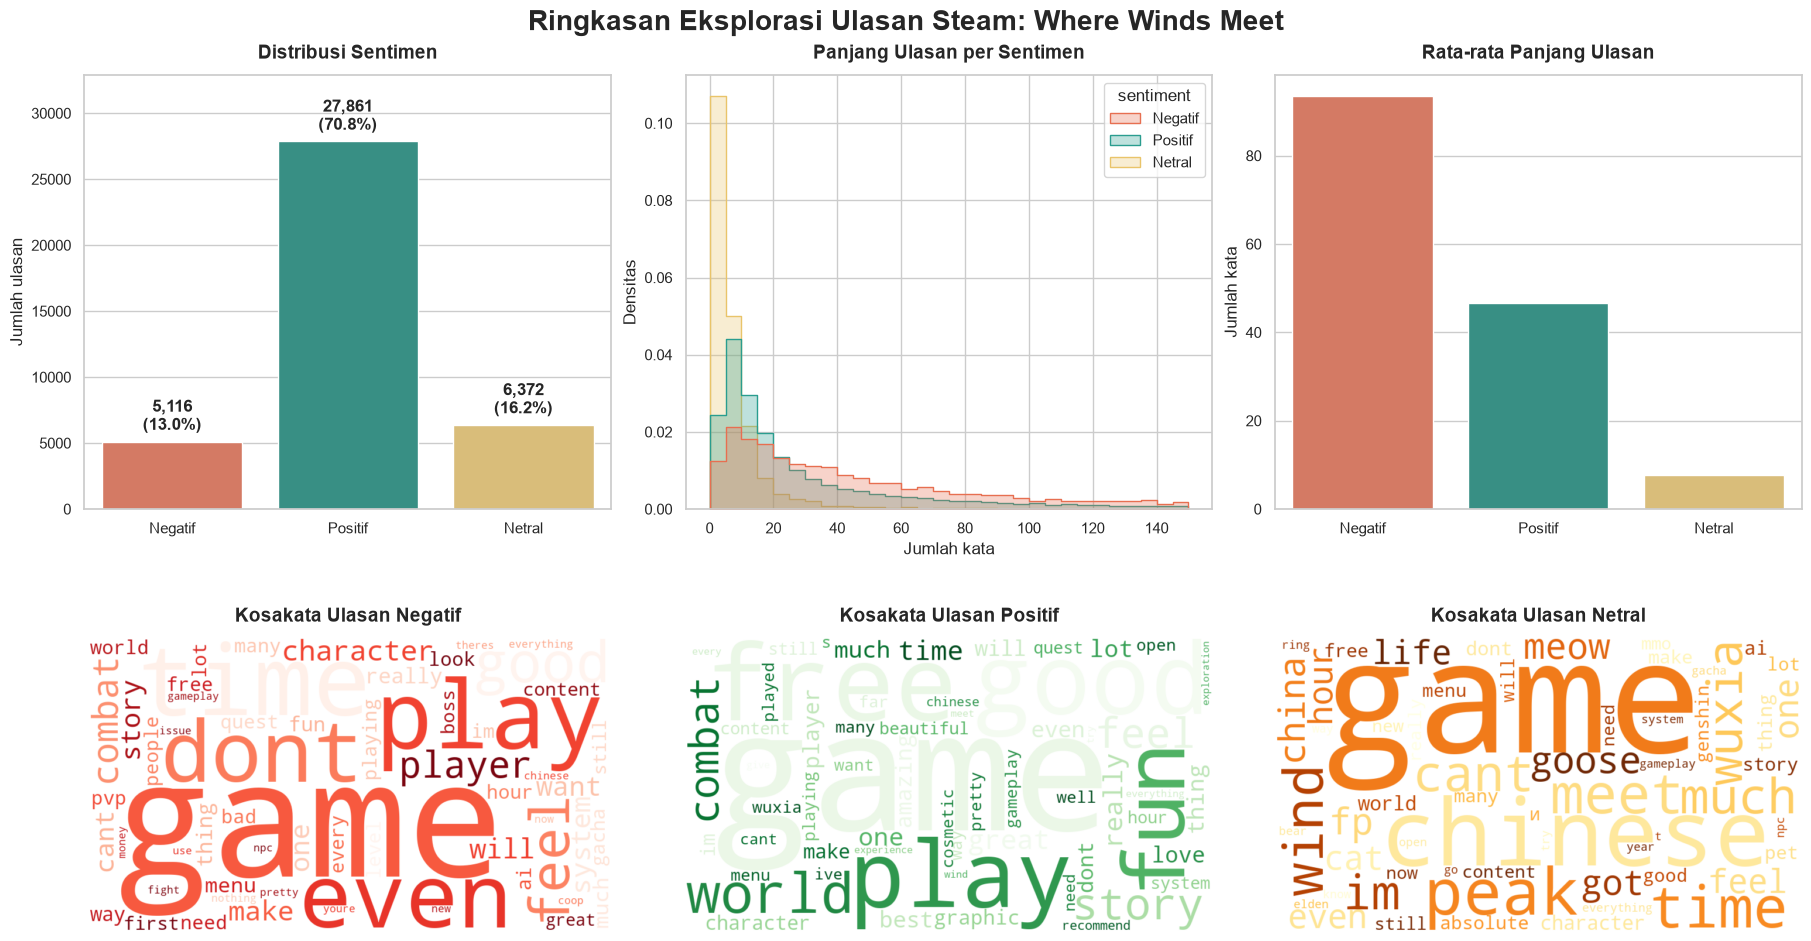

Ringkasan distribusi kelas:
- Negatif: 5,116 (13.0%)
- Positif: 27,861 (70.8%)
- Netral: 6,372 (16.2%)
Rata-rata panjang ulasan:
- Negatif: 93.5 kata
- Positif: 46.5 kata
- Netral: 7.7 kata


In [8]:
# Dashboard EDA untuk tiga kelas sentimen.
sns.set_theme(style='whitegrid')
warna = {0: '#e76f51', 1: '#2a9d8f', 2: '#e9c46a'}
nama_label = {0: 'Negatif', 1: 'Positif', 2: 'Netral'}

# Hitung panjang ulasan sekali dan gunakan data dengan label yang valid.
df['word_count'] = df['cleaned_content'].str.split().str.len()
df['sentiment'] = df['label'].map(nama_label)
label_counts = df['label'].value_counts().reindex([0, 1, 2], fill_value=0)
label_percent = label_counts / label_counts.sum() * 100
rata_panjang = df.groupby('label')['word_count'].mean().reindex([0, 1, 2])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
fig.suptitle('Ringkasan Eksplorasi Ulasan Steam: Where Winds Meet', fontsize=20, fontweight='bold')

# 1. Distribusi jumlah dan proporsi ketiga kelas.
ax = axes[0, 0]
kelas_data = pd.DataFrame({
    'label': [nama_label[0], nama_label[1], nama_label[2]],
    'jumlah': label_counts.values,
    'persentase': label_percent.values
})
sns.barplot(
    data=kelas_data,
    x='label',
    y='jumlah',
    hue='label',
    palette=[warna[0], warna[1], warna[2]],
    legend=False,
    ax=ax
)
ax.set_title('Distribusi Sentimen', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Jumlah ulasan')
ax.set_ylim(0, max(label_counts.max() * 1.18, 1))
for bar, jumlah, persentase in zip(ax.patches, kelas_data['jumlah'], kelas_data['persentase']):
    ax.annotate(
        f'{jumlah:,}\n({persentase:.1f}%)',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold'
    )

# 2. Distribusi panjang ulasan untuk ketiga kelas.
ax = axes[0, 1]
sns.histplot(
    data=df,
    x='word_count',
    hue='sentiment',
    bins=30,
    binrange=(0, min(df['word_count'].quantile(0.99), 150)),
    stat='density',
    common_norm=False,
    element='step',
    fill=True,
    alpha=0.3,
    palette={nama_label[key]: value for key, value in warna.items()},
    hue_order=[nama_label[key] for key in [0, 1, 2]],
    ax=ax
)
ax.set_title('Panjang Ulasan per Sentimen', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah kata')
ax.set_ylabel('Densitas')

# 3. Rata-rata panjang ulasan tiap kelas.
ax = axes[0, 2]
rata_data = pd.DataFrame({
    'label': [nama_label[0], nama_label[1], nama_label[2]],
    'rata_rata_kata': rata_panjang.values
})
sns.barplot(
    data=rata_data,
    x='label',
    y='rata_rata_kata',
    hue='label',
    palette=[warna[0], warna[1], warna[2]],
    legend=False,
    ax=ax
)
ax.set_title('Rata-rata Panjang Ulasan', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Jumlah kata')

# 4-6. Word cloud untuk masing-masing kelas.
for ax, label, judul, colormap in [
    (axes[1, 0], 0, 'Kosakata Ulasan Negatif', 'Reds'),
    (axes[1, 1], 1, 'Kosakata Ulasan Positif', 'Greens'),
    (axes[1, 2], 2, 'Kosakata Ulasan Netral', 'YlOrBr')
]:
    teks = ' '.join(df.loc[df['label'] == label, 'cleaned_content'])
    if teks.strip():
        wordcloud = WordCloud(
            width=900,
            height=500,
            background_color='white',
            colormap=colormap,
            max_words=60,
            prefer_horizontal=0.85,
            collocations=False,
            random_state=42
        ).generate(teks)
        ax.imshow(wordcloud, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center', fontsize=14)
    ax.set_title(judul, fontsize=14, fontweight='bold', pad=12)
    ax.axis('off')

plt.show()

print('Ringkasan distribusi kelas:')
for label in [0, 1, 2]:
    print(f"- {nama_label[label]}: {label_counts.loc[label]:,} ({label_percent.loc[label]:.1f}%)")
print('Rata-rata panjang ulasan:')
for label in [0, 1, 2]:
    print(f"- {nama_label[label]}: {rata_panjang.loc[label]:.1f} kata")

## 7. Persiapan Input untuk Deep Learning
Mengubah teks yang telah dibersihkan menjadi representasi numerik agar dapat diproses oleh model LSTM, CNN, dan Hybrid LSTM-CNN.

### Konfigurasi Tokenizer
Tokenizer dilatih hanya menggunakan data training untuk membangun kosakata, dengan batas ukuran vocabulary dan panjang sequence yang ditentukan.

In [9]:
# Tokenisasi dan Padding untuk model Deep Learning
vocab_size = 10000
max_length = 150
trunc_type = 'post'
pad_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_model)

### Konversi Sequence dan Padding
Teks training, validation, dan testing diubah menjadi sequence angka lalu diseragamkan panjangnya menggunakan padding dan truncation.

In [10]:
# Ubah teks menjadi urutan angka (Sequence)
X_train_seq = tokenizer.texts_to_sequences(X_train_model)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

def pad_texts(sequences):
    return pad_sequences(
        sequences,
        maxlen=max_length,
        padding=pad_type,
        truncating=trunc_type
    )

# Samakan panjang data train, validation, dan test
X_train_padded = pad_texts(X_train_seq)
X_val_padded = pad_texts(X_val_seq)
X_test_padded = pad_texts(X_test_seq)

## 8. Pelatihan Model Deep Learning
Mendefinisikan tiga arsitektur klasifikasi sentimen: LSTM, CNN, dan Hybrid LSTM-CNN. Semua model menggunakan embedding dan konfigurasi loss serta optimizer yang sama.

In [11]:
def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        metrics=['accuracy']
    )
    return model


def build_lstm_model():
    return compile_model(Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
        tf.keras.layers.SpatialDropout1D(0.2),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(0.35),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='LSTM'))


def build_cnn_model():
    return compile_model(Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length),
        tf.keras.layers.SpatialDropout1D(0.2),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.35),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ], name='CNN'))


def build_hybrid_model():
    inputs = tf.keras.Input(shape=(max_length,))
    embedded = Embedding(input_dim=vocab_size, output_dim=128)(inputs)
    features = Conv1D(128, 5, activation='relu', padding='same')(embedded)
    features = Bidirectional(LSTM(128, return_sequences=True))(features)
    features = Bidirectional(LSTM(64))(features)
    features = Dropout(0.35)(features)
    features = Dense(64, activation='relu')(features)
    outputs = Dense(3, activation='softmax')(features)
    return compile_model(tf.keras.Model(inputs, outputs, name='Hybrid_LSTM_CNN'))

model_builders = {
    'LSTM': build_lstm_model,
    'CNN': build_cnn_model,
    'Hybrid LSTM-CNN': build_hybrid_model
}

### Training dan Evaluasi Model
Setiap model dilatih dengan validation set, Early Stopping, dan pengurangan learning rate. Setelah pelatihan, prediksi pada testing set digunakan untuk menghitung Accuracy, Precision, Recall, dan F1-Score.

In [12]:
epochs = 18
batch_size = 64

class_weights = {0: 1.6, 1: 1.0, 2: 1.3}

histories = {}
models = {}
predictions = {}
comparison_rows = []

for model_name, build_model in model_builders.items():
    print(f'\nMelatih model: {model_name}')
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)
    current_model = build_model()
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5, verbose=1)
    ]
    histories[model_name] = current_model.fit(
        X_train_padded, y_train_model,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_padded, y_val),
        class_weight=class_weights,
        callbacks=callbacks,
        shuffle=True,
        verbose=1
    )
    models[model_name] = current_model

    train_probabilities = current_model.predict(X_train_padded, verbose=0)
    train_predictions = train_probabilities.argmax(axis=1)
    test_probabilities = current_model.predict(X_test_padded, verbose=0)
    test_predictions = test_probabilities.argmax(axis=1)
    predictions[model_name] = test_predictions

    train_accuracy = accuracy_score(y_train_model, train_predictions)
    val_accuracy = max(histories[model_name].history['val_accuracy'])
    test_accuracy = accuracy_score(y_test, test_predictions)

    comparison_rows.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Validation Accuracy': val_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': precision_score(y_test, test_predictions, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, test_predictions, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, test_predictions, average='weighted', zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Accuracy', ascending=False)
comparison_df


Melatih model: LSTM



e:\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 236s 545ms/step - accuracy: 0.7579 - loss: 0.7785 - val_accuracy: 0.8135 - val_loss: 0.4609 - learning_rate: 3.0000e-04
Epoch 2/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 217s 551ms/step - accuracy: 0.8651 - loss: 0.4665 - val_accuracy: 0.8679 - val_loss: 0.3497 - learning_rate: 3.0000e-04
Epoch 3/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9111 - loss: 0.3353
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
394/394 ━━━━━━━━━━━━━━━━━━━━ 247s 627ms/step - accuracy: 0.9111 - loss: 0.3353 - val_accuracy: 0.8690 - val_loss: 0.3659 - learning_rate: 3.0000e-04
Epoch 4/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9356 - loss: 0.2628
Epoch 4: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
394/394 ━━━━━━━━━━━━━━━━━━━━ 217s 552ms/step - accuracy: 0.9356 - loss: 0.2628 - val_accuracy: 0.8845 - val_loss: 0.3585 - learning_rate: 1.5000e-04
Epoch 5/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step 

e:\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


394/394 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.7484 - loss: 0.8338 - val_accuracy: 0.8069 - val_loss: 0.4885 - learning_rate: 3.0000e-04
Epoch 2/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8323 - loss: 0.5564 - val_accuracy: 0.8586 - val_loss: 0.3662 - learning_rate: 3.0000e-04
Epoch 3/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.8841 - loss: 0.4071 - val_accuracy: 0.8769 - val_loss: 0.3276 - learning_rate: 3.0000e-04
Epoch 4/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.9111 - loss: 0.3283 - val_accuracy: 0.8856 - val_loss: 0.3212 - learning_rate: 3.0000e-04
Epoch 5/18
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.9307 - loss: 0.2711 - val_accuracy: 0.8875 - val_loss: 0.3211 - learning_rate: 3.0000e-04
Epoch 6/18
393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9433 - loss: 0.2308
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
394/394 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.9

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score
1,CNN,0.959099,0.890407,0.887675,0.886979,0.887675,0.887244
0,LSTM,0.912084,0.885483,0.866074,0.875062,0.866074,0.869414
2,Hybrid LSTM-CNN,0.915022,0.882147,0.857814,0.880997,0.857814,0.864947


Perbandingan performa pada training dan testing set:


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score
1,CNN,0.9591,0.8904,0.8877,0.8870,0.8877,0.8872
0,LSTM,0.9121,0.8855,0.8661,0.8751,0.8661,0.8694
2,Hybrid LSTM-CNN,0.9150,0.8821,0.8578,0.8810,0.8578,0.8649



=== CNN ===
Training Accuracy: 0.9591
Validation Accuracy: 0.8904
Testing Accuracy: 0.8877
              precision    recall  f1-score   support

 Negatif (0)     0.6909    0.6794    0.6851      1023
 Positif (1)     0.9221    0.9331    0.9276      5572
  Netral (2)     0.8907    0.8565    0.8733      1275

    accuracy                         0.8877      7870
   macro avg     0.8346    0.8230    0.8286      7870
weighted avg     0.8870    0.8877    0.8872      7870


=== LSTM ===
Training Accuracy: 0.9121
Validation Accuracy: 0.8855
Testing Accuracy: 0.8661
              precision    recall  f1-score   support

 Negatif (0)     0.6206    0.7546    0.6811      1023
 Positif (1)     0.9337    0.8943    0.9136      5572
  Netral (2)     0.8231    0.8322    0.8276      1275

    accuracy                         0.8661      7870
   macro avg     0.7925    0.8270    0.8074      7870
weighted avg     0.8751    0.8661    0.8694      7870


=== Hybrid LSTM-CNN ===
Training Accuracy: 0.9150
Va

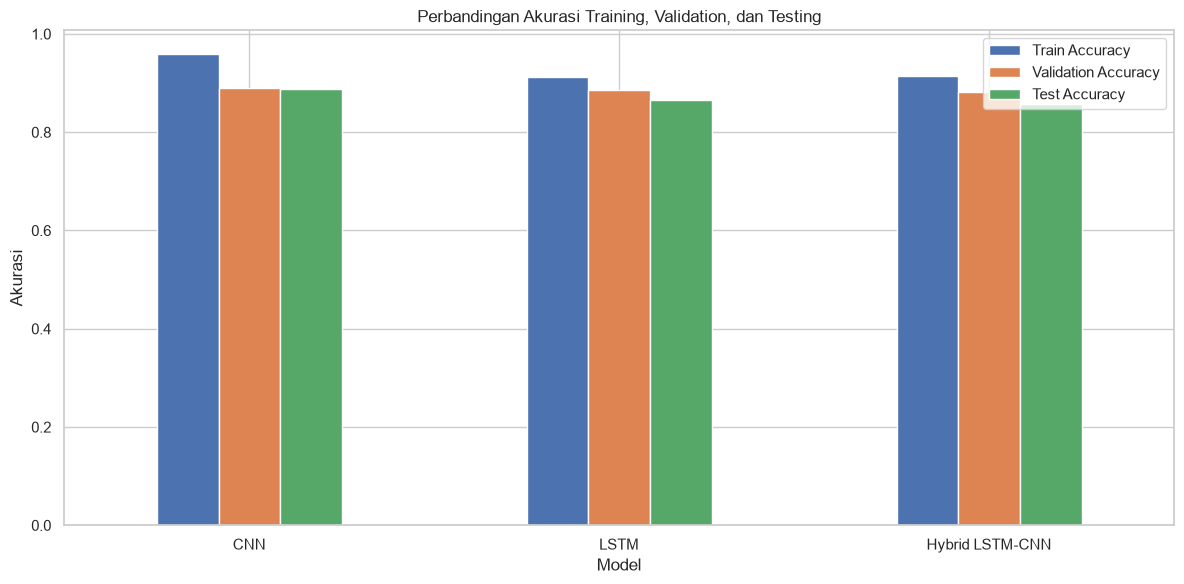

In [13]:
print('Perbandingan performa pada training dan testing set:')
display(comparison_df[['Model', 'Train Accuracy', 'Validation Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4))

for model_name in comparison_df['Model']:
    train_acc = comparison_df.loc[comparison_df['Model'] == model_name, 'Train Accuracy'].iloc[0]
    val_acc = comparison_df.loc[comparison_df['Model'] == model_name, 'Validation Accuracy'].iloc[0]
    test_acc = comparison_df.loc[comparison_df['Model'] == model_name, 'Test Accuracy'].iloc[0]
    print(f'\n=== {model_name} ===')
    print(f'Training Accuracy: {train_acc:.4f}')
    print(f'Validation Accuracy: {val_acc:.4f}')
    print(f'Testing Accuracy: {test_acc:.4f}')
    print(classification_report(
        y_test,
        predictions[model_name],
        target_names=['Negatif (0)', 'Positif (1)', 'Netral (2)'],
        digits=4,
        zero_division=0
    ))

ax = comparison_df.set_index('Model')[['Train Accuracy', 'Validation Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(12, 6), rot=0
)
ax.set_title('Perbandingan Akurasi Training, Validation, dan Testing')
ax.set_ylabel('Akurasi')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

## 9. Inferensi Review Baru
Model terbaik digunakan untuk mengubah review baru menjadi kelas kategorikal. Urutan label yang digunakan adalah `0 = Negatif`, `1 = Positif`, dan `2 = Netral`.

In [14]:
label_names = {0: 'Negatif', 1: 'Positif', 2: 'Netral'}
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]

review_baru = [
    'The combat is fun and the world looks beautiful.',
    'The game crashes constantly and the controls are frustrating.',
    'The game is okay, but the pacing and story are average.'
]
review_baru_clean = [bersihkan_teks(review) for review in review_baru]
review_baru_padded = pad_texts(tokenizer.texts_to_sequences(review_baru_clean))
predicted_labels = best_model.predict(review_baru_padded, verbose=0).argmax(axis=1)

hasil_inferensi = pd.DataFrame({
    'review': review_baru,
    'predicted_label': predicted_labels,
    'predicted_sentiment': [label_names[label] for label in predicted_labels]
})
print(f'Model terbaik: {best_model_name}')
display(hasil_inferensi)

Model terbaik: CNN


,review,predicted_label,predicted_sentiment
0,The combat is fun and the world looks beautiful.,1,Positif
1,The game crashes constantly and the controls a...,0,Negatif
2,"The game is okay, but the pacing and story are...",1,Positif
